mounting and importing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/project/dataset"
print(os.listdir(base_path))

['train', 'val', 'test']


copy data set to collab

In [ ]:
!rm -rf /content/dataset

In [ ]:
!cp -r /content/drive/MyDrive/project/dataset /content/

In [ ]:
import os

print("Images:", len(os.listdir("/content/dataset/train/Color_Images")))
print("Masks:", len(os.listdir("/content/dataset/train/Segmentation")))

Images: 42
Masks: 1902


In [ ]:
!ls /content

dataset  drive	sample_data


updating base path

In [ ]:
base_path = "/content/dataset"
import os
print(os.listdir(base_path))

['val', 'train', 'test']


before everything: yaml running

In [ ]:
%%writefile config.yaml
# Model
model_name: "DeepLabV3Plus"
encoder: "resnet50"
num_classes: 10

# Training
learning_rate: 0.0001
batch_size: 2
epochs: 15
image_size: 512

# Paths
train_images: "/content/dataset/train/Color_Images"
train_masks: "/content/dataset/train/Segmentation"
val_images: "/content/dataset/val/Color_Images"
val_masks: "/content/dataset/val/Segmentation"

Writing config.yaml


some more imports

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

loading image

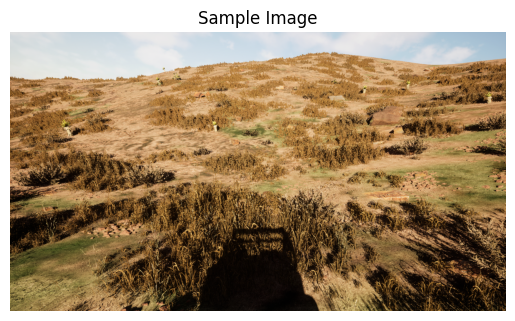

In [ ]:
img_path = "/content/dataset/train/Color_Images/" + os.listdir("/content/dataset/train/Color_Images")[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")
plt.show()

corresponding mask loading

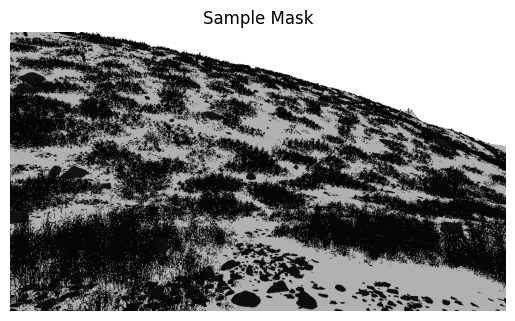

In [ ]:
mask_path = "/content/dataset/train/Segmentation/" + os.listdir("/content/dataset/train/Segmentation")[0]

mask = cv2.imread(mask_path, 0)

plt.imshow(mask, cmap='gray')
plt.title("Sample Mask")
plt.axis("off")
plt.show()

class mapping

In [ ]:
class_mapping = {
    100: 0,
    200: 1,
    300: 2,
    500: 3,
    550: 4,
    600: 5,
    700: 6,
    800: 7,
    7100: 8,
    10000: 9
}

In [ ]:
label_mapping = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    27: 4,
    39: 5
}

dataset class

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class DesertDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images = []

        for root, dirs, files in os.walk(images_dir):
            for file in files:
                if file.endswith('.png'):
                    self.images.append(os.path.join(root, file))

        self.images = sorted(self.images)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]

        mask_name = os.path.basename(img_path)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        # 🔥 map classes
        mask_mapped = np.zeros_like(mask)
        for k, v in label_mapping.items():
            mask_mapped[mask == k] = v

        # 🔥 augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask_mapped)
            image = augmented["image"]
            mask_mapped = augmented["mask"]

        # 🔥 normalize
        image = image / 255.0
        image = np.transpose(image, (2, 0, 1))

        print(img_path)
        print(mask_path)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask_mapped, dtype=torch.long)

defining transforms

In [ ]:
import albumentations as A
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.5),
    A.RandomGamma(p=0.5),
    # ❌ REMOVE THIS:
    # A.CoarseDropout(...)
])


val_transform = A.Compose([
    A.Resize(512, 512)
])

using 512*512 because its:
Divisible by 16 ✔
Fast ✔
No DeepLab errors ✔

path definition

In [ ]:
train_images = "/content/dataset/train/Color_Images"
train_masks = "/content/dataset/train/Segmentation"

val_images = "/content/dataset/val/Color_Images"
val_masks = "/content/dataset/val/Segmentation"

creating dataset objects


In [ ]:
train_dataset = DesertDataset(train_images, train_masks, transform=train_transform)
val_dataset = DesertDataset(val_images, val_masks, transform=val_transform)

creating dataloaders

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    drop_last=True   # 🔥 prevents batchnorm error
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    drop_last=True
)

quivk sanity check

In [ ]:
print(len(train_dataset), len(val_dataset))

42 14


MODEL

In [ ]:
!pip install segmentation_models_pytorch albumentations
import segmentation_models_pytorch as smp
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
!ls /content/dataset/train/Color_Images | wc -l

42


 model definition

In [ ]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=6
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

moving to gpu:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

cpu


loss function

In [ ]:
'''loss_fn = torch.nn.CrossEntropyLoss() -older one, changed to a newer one'''

'loss_fn = torch.nn.CrossEntropyLoss() -older one, changed to a newer one'

In [ ]:
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1e-6):
    pred = F.softmax(pred, dim=1)
    target_one_hot = F.one_hot(target, num_classes=6).permute(0,3,1,2).float()

    intersection = (pred * target_one_hot).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target_one_hot.sum(dim=(2,3))

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()


def focal_loss(pred, target, alpha=0.25, gamma=2):
    ce_loss = F.cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-ce_loss)
    focal = alpha * (1 - pt) ** gamma * ce_loss
    return focal.mean()


def hybrid_loss(pred, target):
    return focal_loss(pred, target) + dice_loss(pred, target)

In [ ]:
loss_fn = hybrid_loss

optimizer

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Training

In [ ]:
def train_model(train_loader):
    model.train()
    total_loss = 0

    for i, (images, masks) in enumerate(train_loader):

        if i % 20 == 0:
            print(f"Batch {i}")

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()   # ✅ correct accumulation

    return total_loss / len(train_loader)

pretraining

In [ ]:
def calculate_iou(preds, masks, num_classes=6):
    ious = []

    preds = preds.view(-1)
    masks = masks.view(-1)

    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = masks == cls

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return sum(ious) / len(ious)

validation

In [ ]:
def validate_model(val_loader):
    model.eval()
    total_loss = 0
    total_iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, masks)
            preds = torch.argmax(outputs, dim=1)
            total_iou += calculate_iou(preds, masks)
            total_loss += loss.item()   # ✅ correct

    return total_loss / len(val_loader), total_iou / len(val_loader)

run training

In [ ]:
epochs = 5

for epoch in range(epochs):
    print(f"\nStarting Epoch {epoch+1}...")

    train_loss = train_model(train_loader)
    val_loss, val_iou = validate_model(val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val IoU: {val_iou:.4f}")   # 🔥 NEW LINE


Starting Epoch 1...
/content/dataset/train/Color_Images/cc0000101.png
/content/dataset/train/Color_Images/cc0000082.png/content/dataset/train/Segmentation/cc0000101.png

/content/dataset/train/Segmentation/cc0000082.png
/content/dataset/train/Color_Images/cc0000109.png
/content/dataset/train/Segmentation/cc0000109.png
/content/dataset/train/Color_Images/cc0000073.png
/content/dataset/train/Segmentation/cc0000073.png
/content/dataset/train/Color_Images/cc0000068.png/content/dataset/train/Color_Images/cc0000072.png

/content/dataset/train/Segmentation/cc0000072.png
/content/dataset/train/Segmentation/cc0000068.png
Batch 0
/content/dataset/train/Color_Images/cc0000098.png
/content/dataset/train/Segmentation/cc0000098.png
/content/dataset/train/Color_Images/cc0000076.png
/content/dataset/train/Segmentation/cc0000076.png
/content/dataset/train/Color_Images/cc0000070.png
/content/dataset/train/Segmentation/cc0000070.png


ValueError: Caught ValueError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_5339/1308504108.py", line 40, in __getitem__
    augmented = self.transform(image=image, mask=mask_mapped)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py", line 607, in __call__
    self.preprocess(data)
  File "/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py", line 641, in preprocess
    self._check_shape_consistency(shapes, volume_shape

visualisation

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
outputs = model(images)

preds = torch.argmax(outputs, dim=1)

images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

import matplotlib.pyplot as plt

for i in range(len(images)):
    plt.figure(figsize=(15,5))

    # Image
    plt.subplot(1,3,1)
    plt.imshow(images[i].transpose(1,2,0))
    plt.title("Input Image")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(masks[i])
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i])
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

In [ ]:
import os
import cv2
import numpy as np

os.makedirs("outputs", exist_ok=True)

model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
outputs = model(images)

preds = torch.argmax(outputs, dim=1)

images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

# Save 10 samples
num_samples = min(10, len(images))

for i in range(num_samples):

    # Convert image to proper format
    img = images[i].transpose(1,2,0)  # CHW → HWC
    img = (img * 255).astype(np.uint8)

    # Scale masks for visibility
    gt = (masks[i] * 40).astype(np.uint8)
    pred = (preds[i] * 40).astype(np.uint8)

    # Save images
    cv2.imwrite(f"outputs/{i}_input.png", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f"outputs/{i}_gt.png", gt)
    cv2.imwrite(f"outputs/{i}_pred.png", pred)

print("✅ Saved 10 samples in 'outputs' folder")

saving images

In [ ]:
import cv2
import os

os.makedirs("outputs", exist_ok=True)

for i in range(len(images)):
    pred_img = (preds[i] * 40).astype('uint8')  # scale for visibility
    cv2.imwrite(f"outputs/pred_{i}.png", pred_img)

debugging

In [ ]:
import numpy as np

sample_mask = cv2.imread("/content/dataset/train/Segmentation/" + os.listdir("/content/dataset/train/Segmentation")[0], 0)

print("Unique values in mask:", np.unique(sample_mask))

adding iou

In [ ]:
def calculate_iou(preds, masks, num_classes=6):
    ious = []

    preds = preds.view(-1)
    masks = masks.view(-1)

    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = masks == cls

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return sum(ious) / len(ious)

In [ ]:
import os

def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.endswith(('.png', '.jpg', '.jpeg')):
                total += 1
    return total

print("Train images:", count_images("/content/dataset/train/Color_Images"))
print("Train masks:", count_images("/content/dataset/train/Segmentation"))

print("Val images:", count_images("/content/dataset/val/Color_Images"))
print("Val masks:", count_images("/content/dataset/val/Segmentation"))

In [ ]:
import os

print("Train image folders:", os.listdir("/content/dataset/train/Color_Images")[:5])

In [ ]:
print(os.listdir("/content/dataset/val"))

In [ ]:
!rsync -ah --progress /content/drive/MyDrive/project/dataset/ /content/dataset/

In [ ]:
import os

print("Train Images:", len(os.listdir("/content/dataset/train/Color_Images")))
print("Train Masks:", len(os.listdir("/content/dataset/train/Segmentation")))

print("Val Images:", len(os.listdir("/content/dataset/val/Color_Images")))
print("Val Masks:", len(os.listdir("/content/dataset/val/Segmentation")))